In [28]:
#TMM Code that I wrote 

import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from scipy.interpolate import PchipInterpolator
import colour

#silicon n-k data extraction
ref_silicon = r"C:\School Stuff\UC Davis\Leite Lab\Data\si.txt"

# Containers/the columns of your data
wavelength_nm_silicon= []
n_vals_si = []
k_vals_si = []

#extracts data from multiple columns 
with open(ref_silicon , "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline()  # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f: #the first horizontal line is read, so now the file pointer is on line two. It will now to start to loop line by line. 
        if not line.strip():
            continue  # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined 

        wl, n, k = line.split() #the horizontal line is split into columns now, and you WILL alter this for your data file to extract column info line by line(row by row). 
        wavelength_nm_silicon.append(float(wl))
        n_vals_si.append(float(n))
        k_vals_si.append(float(k))


# Read the second file with single column
inter_range = r"C:\School Stuff\UC Davis\Leite Lab\Data\Wavelength Range for Interpolation.txt"
interpolation_range = []
with open(inter_range, "r") as f:
    header = f.readline()  # skip header line
    for line in f:
        if not line.strip():
            continue  # skip empty lines
        value = line.strip()
        interpolation_range.append(float(value))

# Converting my reference silicon data from lists --> numpy arrays so that they can be used for calculations. 
wavelengths1= np.array(wavelength_nm_silicon) 
n_data_si = np.array(n_vals_si) #n & k data of silicon 
k_data_si = np.array(k_vals_si) 

# Create the splines for fitting 
pchip_n = PchipInterpolator(wavelengths1, n_data_si)
pchip_k = PchipInterpolator(wavelengths1, k_data_si)

# Interpolate at any x values(wavelengths) within your range
wavelengths_exp = np.array(interpolation_range)  #This is the wavelength range from margaret's data 
n_new_si = pchip_n(wavelengths_exp) #this is now going to use the wavelength range as the input for the interpolation functions 
k_new_si = pchip_k(wavelengths_exp)

#extracting Margaret's experimental Data

md_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\am2c14613_si_001.txt"

#initialize the lists
wl_exp = []
e1_Mo = []
e2_Mo = []
e1_Ru = []
e2_Ru = []
e1_Ta = []
e2_Ta = []
e1_W = []
e2_W = []
e1_MoO3 = []
e2_MoO3 = []
e1_RuO2 = []
e2_RuO2 = []
e1_Ta2O5 = []
e2_Ta2O5 = []
e1_WO3 = []
e2_WO3 = []

with open(md_data, 'r') as f:
    header = f.readline() #stores header information and disregards it 
    for line in f:
        if not line.strip(): #if there's nothing in the line, skip it 
            continue 

        #Split the text file into columns, the file is split by tabs, not spaces
        values = line.split('\t') #if it was split by spaces the argument would be empty 
                                  #since there are 17 columns the index goes from 0 --> 16 

        wl_exp.append(float(values[0]))
        e1_Mo.append(float(values[1]))
        e2_Mo.append(float(values[2]))
        e1_Ru.append(float(values[3]))
        e2_Ru.append(float(values[4]))
        e1_Ta.append(float(values[5]))
        e2_Ta.append(float(values[6]))
        e1_W.append(float(values[7]))
        e2_W.append(float(values[8]))
        e1_MoO3.append(float(values[9]))
        e2_MoO3.append(float(values[10]))
        e1_RuO2.append(float(values[11]))
        e2_RuO2.append(float(values[12]))
        e1_Ta2O5.append(float(values[13]))
        e2_Ta2O5.append(float(values[14]))
        e1_WO3.append(float(values[15]))
        e2_WO3.append(float(values[16]))

wl_exp_array = np.array(wl_exp)
e1_Mo_array = np.array(e1_Mo)
e2_Mo_array = np.array(e2_Mo)
e1_Ru_array = np.array(e1_Ru)
e2_Ru_array = np.array(e2_Ru)
e1_Ta_array = np.array(e1_Ta)
e2_Ta_array = np.array(e2_Ta)
e1_W_array = np.array(e1_W)
e2_W_array = np.array(e2_W)
e1_MoO3_array = np.array(e1_MoO3)
e2_MoO3_array = np.array(e2_MoO3)
e1_RuO2_array = np.array(e1_RuO2)
e2_RuO2_array = np.array(e2_RuO2)
e1_Ta2O5_array = np.array(e1_Ta2O5)
e2_Ta2O5_array = np.array(e2_Ta2O5)
e1_WO3_array = np.array(e1_WO3)
e2_WO3_array = np.array(e2_WO3)

#cutting off data for all wavelengths below 299 nm 

idx = np.argmin(np.abs(wl_exp_array - 300)) #finding the index for filtering 

wl_exp_array_filtered = wl_exp_array[idx:]
e1_Mo_array_filtered = e1_Mo_array[idx:]
e2_Mo_array_filtered = e2_Mo_array[idx:]
e1_Ru_array_filtered = e1_Ru_array[idx:]
e2_Ru_array_filtered = e2_Ru_array[idx:]
e1_Ta_array_filtered = e1_Ta_array[idx:]
e2_Ta_array_filtered = e2_Ta_array[idx:]
e1_W_array_filtered = e1_W_array[idx:]
e2_W_array_filtered = e2_W_array[idx:]
e1_MoO3_array_filtered = e1_MoO3_array[idx:]
e2_MoO3_array_filtered = e2_MoO3_array[idx:]
e1_RuO2_array_filtered = e1_RuO2_array[idx:]
e2_RuO2_array_filtered = e2_RuO2_array[idx:]
e1_Ta2O5_array_filtered = e1_Ta2O5_array[idx:]
e2_Ta2O5_array_filtered = e2_Ta2O5_array[idx:]
e1_WO3_array_filtered = e1_WO3_array[idx:]
e2_WO3_array_filtered = e2_WO3_array[idx:]

#Functions for calculating the real and imaginary parts of the refractive index, and then giving the total complex one. 

def refract_index_REDO(eps_real, eps_im):
    eps_complex = eps_real + 1j * eps_im
    n_complex = np.sqrt(eps_complex) 
    return n_complex 

def theta_transmit(theta_incident, n1, n2): #where n1 and n2 refer to the index of refraction of the material the light is currently in and the material the light enters, respectively. 
    return np.arcsin(n1 / n2 * np.sin(theta_incident)) #make sure that the very first theta incident is pi/2 radians, don't put in 90 because it's not in degrees

def coeffs(n_incident, n_transmit, theta_incident, theta_transmit):
    r_s = (n_incident * np.cos(theta_incident) - n_transmit * np.cos(theta_transmit)) / (n_incident * np.cos(theta_incident) + n_transmit * np.cos(theta_transmit))
    t_s = (2 * n_incident * np.cos(theta_incident)) / (n_incident * np.cos(theta_incident) + n_transmit * np.cos(theta_transmit))
    r_p = (n_transmit * np.cos(theta_incident) - n_incident * np.cos(theta_transmit)) / (n_transmit * np.cos(theta_incident) + n_incident * np.cos(theta_transmit))
    t_p = (2 * n_transmit * np.cos(theta_incident)) / (n_transmit * np.cos(theta_incident) + n_incident * np.cos(theta_transmit))
    return r_s, t_s, r_p, t_p 
    
def phi_j(lamb, n_complex, thickness, theta_incident):
    return (2 * np.pi) * (n_complex) * (thickness) * np.cos(theta_incident) / (lamb) 

def prop_matrix(phi):
    return np.array([[np.exp(-1j*phi), 0],
                     [0, np.exp(1j*phi)]])

def sp_tmatrix(t,r):
    return (1/t) * np.array([[1, r],
                             [r, 1]])

def pp_tmatrix(t,r):
    return (1/t) * np.array([[1, r],
                             [r, 1]])
    
def calc_reflectivity(M21, M11):
    return (np.abs(M21 / M11))**2

#Actual Calculations
def compute_reflectivity_stack(wavelengths, thickness_oxide, n_oxide_array, n_metal_array, n_si_array, theta_incident, n_air, thick_metal):
    
    reflectivity_stack = []

    for thickness in thickness_oxide: #all fo the values for each thickness end up becoming a row in reflectivity_stack 
        reflectivity_at_this_thickness = []

        for i, wavelength in enumerate(wavelengths):

            n_oxide = n_oxide_array[i]
            n_metal = n_metal_array[i]
            n_si = n_si_array[i]

            # transmitted angles
            theta_A2O = theta_transmit(theta_incident, n_air, n_oxide)
            theta_O2M = theta_transmit(theta_A2O, n_oxide, n_metal)
            theta_M2SIL = theta_transmit(theta_O2M, n_metal, n_si)

            # Fresnel coefficients
            r_sA2O, t_sA2O, r_pA2O, t_pA2O = coeffs(n_air, n_oxide, theta_incident, theta_A2O)
            r_sO2M, t_sO2M, r_pO2M, t_pO2M = coeffs(n_oxide, n_metal, theta_A2O, theta_O2M)
            r_sM2SIL, t_sM2SIL, r_pM2SIL, t_pM2SIL = coeffs(n_metal, n_si, theta_O2M, theta_M2SIL)

            # phase factors
            phi_oxide = phi_j(wavelength, n_oxide, thickness, theta_A2O)
            phi_metal = phi_j(wavelength, n_metal, thick_metal, theta_O2M)

            # propagation matrices
            P_oxide = prop_matrix(phi_oxide)
            P_metal = prop_matrix(phi_metal)

            # transfer matrices, s and p polarizations respectively 
            sp_A2O = sp_tmatrix(t_sA2O, r_sA2O)
            sp_O2M = sp_tmatrix(t_sO2M, r_sO2M)
            sp_M2SIL = sp_tmatrix(t_sM2SIL, r_sM2SIL)

            pp_A2O = sp_tmatrix(t_pA2O, r_pA2O)
            pp_O2M = sp_tmatrix(t_pO2M, r_pO2M)
            pp_M2SIL = sp_tmatrix(t_pM2SIL, r_pM2SIL)

            # total transfer matrices, s and p polarizations, respectively 
            M_sp = sp_A2O @ P_oxide @ sp_O2M @ P_metal @ sp_M2SIL
            M_pp = pp_A2O @ P_oxide @ pp_O2M @ P_metal @ pp_M2SIL

            # reflectivities
            R_sp = calc_reflectivity(M_sp[1,0], M_sp[0,0])
            R_pp = calc_reflectivity(M_pp[1,0], M_pp[0,0])

            R_avg = (R_sp + R_pp) / 2

            reflectivity_at_this_thickness.append(R_avg)

        reflectivity_stack.append(reflectivity_at_this_thickness)

    return reflectivity_stack

#initializing variables that will always be constant/need to be outside of the loop 
thick_metal = 20 #in units of nm
n_air = 1 #index of refraction of air 
thickness_oxide = np.arange(0, 105, 5) #also in units of nm, the oxide thicknesses. Step size of 5 nm, from 0 --> 100 nm 
theta_incident = (np.pi / 180) * 0 # You can either put in your incident angle directly as radians or put it in as degrees and then convert it to radians. 


#defining input wavelengths, filtered just means from 300 nm --> onwards 
inp_wl = wl_exp_array_filtered #the wavelengths I'm going to be using for the calculations 
inp_wl_full = wl_exp_array #covers the wholer ange from 188 --> onwards 

#calculating refractive indices, I have the filtered values for now because that's what I used for the normalization, keep a close eye on Tantalum 04-15-26
n_RuO2_array = [refract_index_REDO(e1_RuO2_array_filtered[i], e2_RuO2_array_filtered[i]) for i in range(len(inp_wl))]
n_Ru_array = [refract_index_REDO(e1_Ru_array_filtered[i], e2_Ru_array_filtered[i]) for i in range(len(inp_wl))]

n_Ta2O5_array = [refract_index_REDO(e1_Ta2O5_array_filtered[i], e2_Ta2O5_array_filtered[i]) for i in range(len(inp_wl))]
n_Ta_array = [refract_index_REDO(e1_Ta_array_filtered[i], e2_Ta_array_filtered[i]) for i in range(len(inp_wl))]

n_WO3_array = [refract_index_REDO(e1_WO3_array_filtered[i], e2_WO3_array_filtered[i]) for i in range(len(inp_wl))]
n_W_array = [refract_index_REDO(e1_W_array_filtered[i], e2_W_array_filtered[i]) for i in range(len(inp_wl))]

n_si_array = [n_new_si[i] + 1j*k_new_si[i] for i in range(len(inp_wl))]

reflectivity_Ru = compute_reflectivity_stack(inp_wl, thickness_oxide, n_RuO2_array, n_Ru_array, n_si_array, theta_incident, n_air, thick_metal)
reflectivity_Ta = compute_reflectivity_stack(inp_wl, thickness_oxide, n_Ta2O5_array, n_Ta_array, n_si_array, theta_incident, n_air, thick_metal)
reflectivity_W = compute_reflectivity_stack(inp_wl, thickness_oxide, n_WO3_array, n_W_array, n_si_array, theta_incident, n_air, thick_metal)

#converting to np.arrays 

R_Ru = np.array(reflectivity_Ru)
R_Ta = np.array(reflectivity_Ta)
R_W = np.array(reflectivity_W) 

R_Ru_norm_ALL = []
R_Ta_norm_ALL = []
R_W_norm_ALL = []

for i, thickness in enumerate(thickness_oxide):
    
    #Using 'min-max' normalization
    R_Ru_norm= np.array( (R_Ru[i] - np.min(R_Ru[i])) / (np.max(R_Ru[i]) - np.min(R_Ru[i])) )
    R_Ta_norm= np.array( (R_Ta[i] - np.min(R_Ta[i])) / (np.max(R_Ta[i]) - np.min(R_Ta[i])) )
    R_W_norm= np.array( (R_W[i] - np.min(R_W[i])) / (np.max(R_W[i]) - np.min(R_W[i])) )

    R_Ru_norm_ALL.append(R_Ru_norm)
    R_Ta_norm_ALL.append(R_Ta_norm)
    R_W_norm_ALL.append(R_W_norm)

#normalized values
R_Ru_norm_ALL = np.array(R_Ru_norm_ALL)
R_Ta_norm_ALL = np.array(R_Ta_norm_ALL)
R_W_norm_ALL = np.array(R_W_norm_ALL)

#Restricting to the visible range 
visible = (inp_wl >= 380) & (inp_wl <= 780) #restricting the data over the visible range --> color gamuts only show visible spectrum (human vision range used in CIE color matching)

wl_visible = inp_wl[visible] #only give me the wavelengths in the range defined in 'visible'
R_Ru_visible = R_Ru[:, visible] #give me all the rows(i.e. all the thicknesses and the data in these rows within the visible spectrum 
R_Ta_visible = R_Ta[:, visible] #give me all the rows(i.e. all the thicknesses and the data in these rows within the visible spectrum 
R_W_visible = R_W[:, visible] #give me all the rows(i.e. all the thicknesses and the data in these rows within the visible spectrum 

R_Ru_visible_norm = R_Ru_norm_ALL[:, visible] #give me all the rows(i.e. all the thicknesses and the data in these rows within the visible spectrum 
R_Ta_visible_norm = R_Ta_norm_ALL[:, visible] #give me all the rows(i.e. all the thicknesses and the data in these rows within the visible spectrum 
R_W_visible_norm = R_W_norm_ALL[:, visible] #give me all the rows(i.e. all the thicknesses and the data in these rows within the visible spectrum


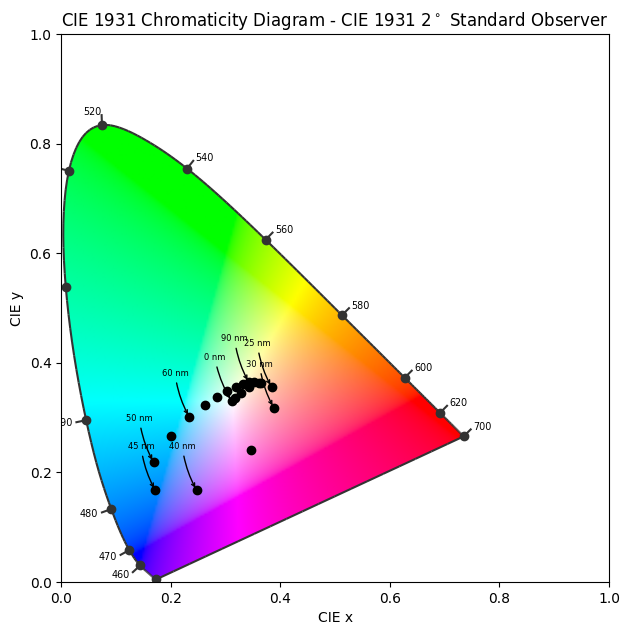

(<Figure size 640x640 with 1 Axes>,
 <Axes: title={'center': 'CIE 1931 Chromaticity Diagram - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='CIE x', ylabel='CIE y'>)

In [10]:
#To access the specific reflectivity spectra for a given thickness the index convention is as follows
#reflectivity_metal[0] --> spectra for 10 nm oxide thickness 
#reflectivity_metal[1] --> spectra for 15 nm oxide thickness 
#and so on and so forth in steps of 5 for each metal until you get to 100 nm thickness. 

#cmfs and illuminant are for modeling human perception of light 
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"] #cmfs == 'color mapping functions' as defined by the model in the argument, which is basically the
                                                                #default model that people use for human eyes 
illuminant = colour.SDS_ILLUMINANTS["D65"] #an illuminant is basically your light source spectrum. D = Daylight , 65 = 6500K color temperature --> 'average midday sunlight' 

gamuts = []

shape = colour.SpectralShape(380, 780, 1) #apparently, when computing the tristumlus values, which are essentially integrals (see doc), the interval
                                          #spacing for your wavelength has to be an integer of 1, 5, 10, or 20 nm, so if it's not, you need to interpolate 
                                          #over your wavelength range with one of these integer spacings 

# irregularly spaced data
wavelengths_old = wl_visible  #380 nm --> 780 nm, but not spaced by an integer of 1, 5, 10 or 20 nm. 

#Data I want to interpolate over 
wavelengths_new = np.arange(380, 781, 1)  #380 nm --> 780 nm, but spaced by an integer of 1 nm 

for i, thickness in enumerate(thickness_oxide): 
   
    R_curve = R_Ru_visible[i, :] #defining the reflectivity that we need to interpolate over
    
    Pchip_R = PchipInterpolator(wavelengths_old, R_curve) #construct an interpolation 
    
    R_new = Pchip_R(wavelengths_new) #getting the interpolated values 

    spectrum_input = dict(zip(wavelengths_new, R_new)) #zip essentially takes two arrays with the same dimensions and creates tuples out of the elements in the same position
                                                              # GPT: 'pairs each wavelength with corresponding reflectivity value (truncates to shortest length if mismatched)'
    
    spectrum = colour.SpectralDistribution(dict(zip(wavelengths_new, R_new))).align(shape) #creates the spectral distribution of a structure with that Reflectivity at a given thickness
    
    XYZ = colour.sd_to_XYZ(spectrum, cmfs, illuminant) # converting the spectral distribution to tristimulus values, 
                                                       # X represents a visual response to red-green light, Y is the luminance/brightness, Z = blue response
    
    xy = colour.XYZ_to_xy(XYZ) #converts from tristimulus values to coordinates that can be plotted on a chromaticity diagram, each structure has one (x,y) coordinate
                               #this (x,y) coordinate tells us what color the stack is going to have under daylight illumination 

    gamuts.append(xy) #appends the coordinates to the array, and by plotting all of them we get the chromaticity diagram to show how color changes w/oxide thickness 

gamut_pts = np.array(gamuts) 

# Plotting the *CIE 1931 Chromaticity Diagram*.
# The argument *show=False* is passed so that the plot doesn't get
# displayed and can be used as a basis for other plots.

colour.plotting.plot_chromaticity_diagram_CIE1931(show=False)

# Plotting the *CIE xy* chromaticity coordinates.
x, y = gamut_pts[:, 0], gamut_pts[:, 1] #getting all the x-values and all the y-values
plt.plot(x, y, "o", color = 'black')



for i, thickness in enumerate(thickness_oxide):
    if i in [0, 5, 6, 8, 9, 10, 12, 18]:
        plt.annotate(f"{thickness} nm", xy = (x[i], y[i]), xytext=(-20, 30), textcoords="offset points", fontsize = 6, arrowprops=dict(arrowstyle="->", connectionstyle = "arc3, rad = 0.1"))

# Displaying the plot.
colour.plotting.render(show=True, limits=(-0.1, 0.9, -0.1, 0.9), x_tighten=True, y_tighten=True)

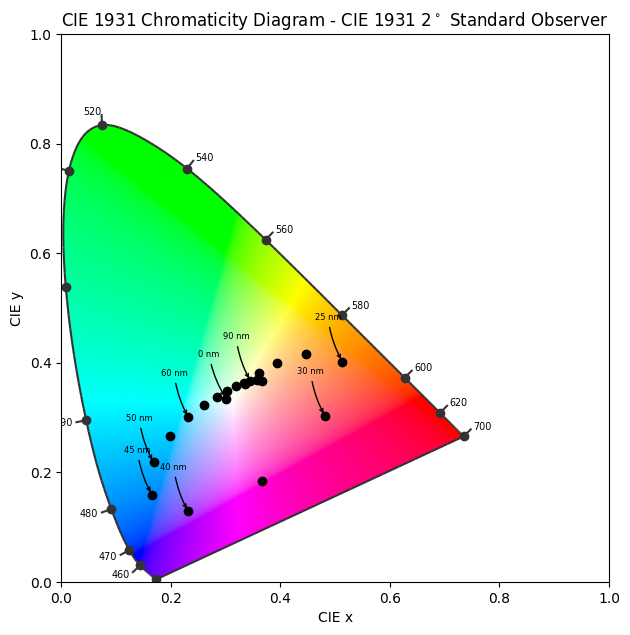

(<Figure size 640x640 with 1 Axes>,
 <Axes: title={'center': 'CIE 1931 Chromaticity Diagram - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='CIE x', ylabel='CIE y'>)

In [45]:
#To access the specific reflectivity spectra for a given thickness the index convention is as follows
#reflectivity_metal[0] --> spectra for 10 nm oxide thickness 
#reflectivity_metal[1] --> spectra for 15 nm oxide thickness 
#and so on and so forth in steps of 5 for each metal until you get to 100 nm thickness. 

#cmfs and illuminant are for modeling human perception of light 
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"] #cmfs == 'color mapping functions' as defined by the model in the argument, which is basically the
                                                                #default model that people use for human eyes 
illuminant = colour.SDS_ILLUMINANTS["D65"] #an illuminant is basically your light source spectrum. D = Daylight , 65 = 6500K color temperature --> 'average midday sunlight' 

gamuts = []

shape = colour.SpectralShape(380, 780, 1) #apparently, when computing the tristumlus values, which are essentially integrals (see doc), the interval
                                          #spacing for your wavelength has to be an integer of 1, 5, 10, or 20 nm, so if it's not, you need to interpolate 
                                          #over your wavelength range with one of these integer spacings 

# irregularly spaced data
wavelengths_old = wl_visible  #380 nm --> 780 nm, but not spaced by an integer of 1, 5, 10 or 20 nm. 

#Data I want to interpolate over 
wavelengths_new = np.arange(380, 781, 1)  #380 nm --> 780 nm, but spaced by an integer of 1 nm 

for i, thickness in enumerate(thickness_oxide): 
   
    R_curve = R_Ru_visible_norm[i, :] #defining the reflectivity that we need to interpolate over
    
    Pchip_R = PchipInterpolator(wavelengths_old, R_curve) #construct an interpolation 
    
    R_new = Pchip_R(wavelengths_new) #getting the interpolated values 

    spectrum_input = dict(zip(wavelengths_new, R_new)) #zip essentially takes two arrays with the same dimensions and creates tuples out of the elements in the same position
                                                              # GPT: 'pairs each wavelength with corresponding reflectivity value (truncates to shortest length if mismatched)'
    
    spectrum = colour.SpectralDistribution(dict(zip(wavelengths_new, R_new))).align(shape) #creates the spectral distribution of a structure with that Reflectivity at a given thickness
    
    XYZ = colour.sd_to_XYZ(spectrum, cmfs, illuminant) # converting the spectral distribution to tristimulus values, 
                                                       # X represents a visual response to red-green light, Y is the luminance/brightness, Z = blue response
    
    xy = colour.XYZ_to_xy(XYZ) #converts from tristimulus values to coordinates that can be plotted on a chromaticity diagram, each structure has one (x,y) coordinate
                               #this (x,y) coordinate tells us what color the stack is going to have under daylight illumination 

    gamuts.append(xy) #appends the coordinates to the array, and by plotting all of them we get the chromaticity diagram to show how color changes w/oxide thickness 

gamut_pts = np.array(gamuts) 

# Plotting the *CIE 1931 Chromaticity Diagram*.
# The argument *show=False* is passed so that the plot doesn't get
# displayed and can be used as a basis for other plots.

colour.plotting.plot_chromaticity_diagram_CIE1931(show=False)

# Plotting the *CIE xy* chromaticity coordinates.
x, y = gamut_pts[:, 0], gamut_pts[:, 1] #getting all the x-values and all the y-values
plt.plot(x, y, "o", color = 'black')



for i, thickness in enumerate(thickness_oxide):
    if i in [0, 5, 6, 8, 9, 10, 12, 18]:
        plt.annotate(f"{thickness} nm", xy = (x[i], y[i]), xytext=(-20, 30), textcoords="offset points", fontsize = 6, arrowprops=dict(arrowstyle="->", connectionstyle = "arc3, rad = 0.1"))

# Displaying the plot.
colour.plotting.render(show=True, limits=(-0.1, 0.9, -0.1, 0.9), x_tighten=True, y_tighten=True)

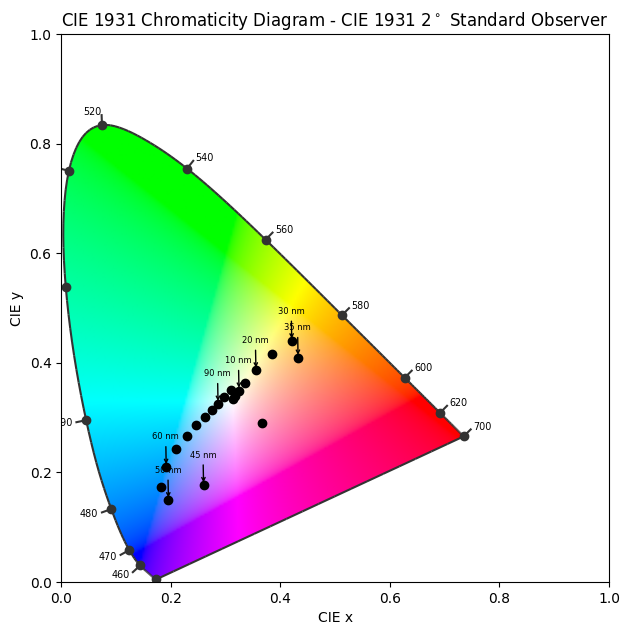

(<Figure size 640x640 with 1 Axes>,
 <Axes: title={'center': 'CIE 1931 Chromaticity Diagram - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='CIE x', ylabel='CIE y'>)

In [8]:
#To access the specific reflectivity spectra for a given thickness the index convention is as follows
#reflectivity_metal[0] --> spectra for 10 nm oxide thickness 
#reflectivity_metal[1] --> spectra for 15 nm oxide thickness 
#and so on and so forth in steps of 5 for each metal until you get to 100 nm thickness. 

#cmfs and illuminant are for modeling human perception of light 
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"] #cmfs == 'color mapping functions' as defined by the model in the argument, which is basically the
                                                                #default model that people use for human eyes 
illuminant = colour.SDS_ILLUMINANTS["D65"] #an illuminant is basically your light source spectrum. D = Daylight , 65 = 6500K color temperature --> 'average midday sunlight' 

gamuts = []

shape = colour.SpectralShape(380, 780, 1) #apparently, when computing the tristumlus values, which are essentially integrals (see doc), the interval
                                          #spacing for your wavelength has to be an integer of 1, 5, 10, or 20 nm, so if it's not, you need to interpolate 
                                          #over your wavelength range with one of these integer spacings 

# irregularly spaced data
wavelengths_old = wl_visible  #380 nm --> 780 nm, but not spaced by an integer of 1, 5, 10 or 20 nm. 

#Data I want to interpolate over 
wavelengths_new = np.arange(380, 781, 1)  #380 nm --> 780 nm, but spaced by an integer of 1 nm 

for i, thickness in enumerate(thickness_oxide): 
   
    R_curve = R_Ta_visible[i, :] #defining the reflectivity that we need to interpolate over
    
    Pchip_R = PchipInterpolator(wavelengths_old, R_curve) #construct an interpolation 
    
    R_new = Pchip_R(wavelengths_new) #getting the interpolated values 

    spectrum_input = dict(zip(wavelengths_new, R_new)) #zip essentially takes two arrays with the same dimensions and creates tuples out of the elements in the same position
                                                              # GPT: 'pairs each wavelength with corresponding reflectivity value (truncates to shortest length if mismatched)'
    
    spectrum = colour.SpectralDistribution(dict(zip(wavelengths_new, R_new))).align(shape) #creates the spectral distribution of a structure with that Reflectivity at a given thickness
    
    XYZ = colour.sd_to_XYZ(spectrum, cmfs, illuminant) # converting the spectral distribution to tristimulus values, 
                                                       # X represents a visual response to red-green light, Y is the luminance/brightness, Z = blue response
    
    xy = colour.XYZ_to_xy(XYZ) #converts from tristimulus values to coordinates that can be plotted on a chromaticity diagram, each structure has one (x,y) coordinate
                               #this (x,y) coordinate tells us what color the stack is going to have under daylight illumination 

    gamuts.append(xy) #appends the coordinates to the array, and by plotting all of them we get the chromaticity diagram to show how color changes w/oxide thickness 

gamut_pts = np.array(gamuts) 

# Plotting the *CIE 1931 Chromaticity Diagram*.
# The argument *show=False* is passed so that the plot doesn't get
# displayed and can be used as a basis for other plots.

colour.plotting.plot_chromaticity_diagram_CIE1931(show=False)

# Plotting the *CIE xy* chromaticity coordinates.
x, y = gamut_pts[:, 0], gamut_pts[:, 1] #getting all the x-values and all the y-values
plt.plot(x, y, "o", color = 'black')



for i, thickness in enumerate(thickness_oxide):
    if i in [2, 4, 6, 7, 9, 10, 12, 18]:
        plt.annotate(f"{thickness} nm", xy = (x[i], y[i]), xytext=(-10, 20), textcoords="offset points", fontsize = 6, arrowprops=dict(arrowstyle="->", connectionstyle = "arc3, rad = 0.0"))

# Displaying the plot.
colour.plotting.render(show=True, limits=(-0.1, 0.9, -0.1, 0.9), x_tighten=True, y_tighten=True)

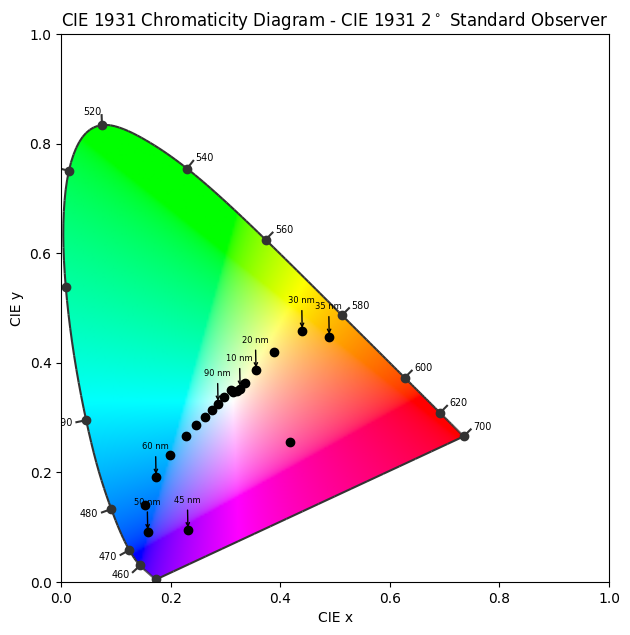

(<Figure size 640x640 with 1 Axes>,
 <Axes: title={'center': 'CIE 1931 Chromaticity Diagram - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='CIE x', ylabel='CIE y'>)

In [46]:
#To access the specific reflectivity spectra for a given thickness the index convention is as follows
#reflectivity_metal[0] --> spectra for 10 nm oxide thickness 
#reflectivity_metal[1] --> spectra for 15 nm oxide thickness 
#and so on and so forth in steps of 5 for each metal until you get to 100 nm thickness. 

#cmfs and illuminant are for modeling human perception of light 
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"] #cmfs == 'color mapping functions' as defined by the model in the argument, which is basically the
                                                                #default model that people use for human eyes 
illuminant = colour.SDS_ILLUMINANTS["D65"] #an illuminant is basically your light source spectrum. D = Daylight , 65 = 6500K color temperature --> 'average midday sunlight' 

gamuts = []

shape = colour.SpectralShape(380, 780, 1) #apparently, when computing the tristumlus values, which are essentially integrals (see doc), the interval
                                          #spacing for your wavelength has to be an integer of 1, 5, 10, or 20 nm, so if it's not, you need to interpolate 
                                          #over your wavelength range with one of these integer spacings 

# irregularly spaced data
wavelengths_old = wl_visible  #380 nm --> 780 nm, but not spaced by an integer of 1, 5, 10 or 20 nm. 

#Data I want to interpolate over 
wavelengths_new = np.arange(380, 781, 1)  #380 nm --> 780 nm, but spaced by an integer of 1 nm 

for i, thickness in enumerate(thickness_oxide): 
   
    R_curve = R_Ta_visible_norm[i, :] #defining the reflectivity that we need to interpolate over
    
    Pchip_R = PchipInterpolator(wavelengths_old, R_curve) #construct an interpolation 
    
    R_new = Pchip_R(wavelengths_new) #getting the interpolated values 

    spectrum_input = dict(zip(wavelengths_new, R_new)) #zip essentially takes two arrays with the same dimensions and creates tuples out of the elements in the same position
                                                              # GPT: 'pairs each wavelength with corresponding reflectivity value (truncates to shortest length if mismatched)'
    
    spectrum = colour.SpectralDistribution(dict(zip(wavelengths_new, R_new))).align(shape) #creates the spectral distribution of a structure with that Reflectivity at a given thickness
    
    XYZ = colour.sd_to_XYZ(spectrum, cmfs, illuminant) # converting the spectral distribution to tristimulus values, 
                                                       # X represents a visual response to red-green light, Y is the luminance/brightness, Z = blue response
    
    xy = colour.XYZ_to_xy(XYZ) #converts from tristimulus values to coordinates that can be plotted on a chromaticity diagram, each structure has one (x,y) coordinate
                               #this (x,y) coordinate tells us what color the stack is going to have under daylight illumination 

    gamuts.append(xy) #appends the coordinates to the array, and by plotting all of them we get the chromaticity diagram to show how color changes w/oxide thickness 

gamut_pts = np.array(gamuts) 

# Plotting the *CIE 1931 Chromaticity Diagram*.
# The argument *show=False* is passed so that the plot doesn't get
# displayed and can be used as a basis for other plots.

colour.plotting.plot_chromaticity_diagram_CIE1931(show=False)

# Plotting the *CIE xy* chromaticity coordinates.
x, y = gamut_pts[:, 0], gamut_pts[:, 1] #getting all the x-values and all the y-values
plt.plot(x, y, "o", color = 'black')



for i, thickness in enumerate(thickness_oxide):
    if i in [2, 4, 6, 7, 9, 10, 12, 18]:
        plt.annotate(f"{thickness} nm", xy = (x[i], y[i]), xytext=(-10, 20), textcoords="offset points", fontsize = 6, arrowprops=dict(arrowstyle="->", connectionstyle = "arc3, rad = 0.0"))

# Displaying the plot.
colour.plotting.render(show=True, limits=(-0.1, 0.9, -0.1, 0.9), x_tighten=True, y_tighten=True)

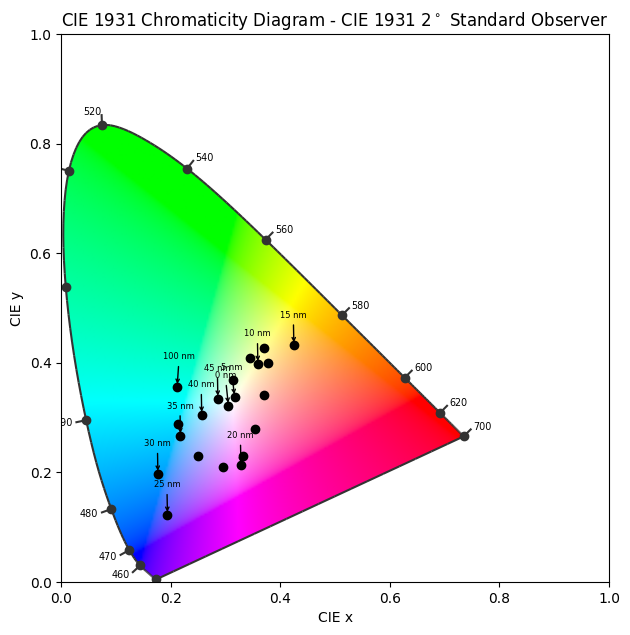

(<Figure size 640x640 with 1 Axes>,
 <Axes: title={'center': 'CIE 1931 Chromaticity Diagram - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='CIE x', ylabel='CIE y'>)

In [22]:
#To access the specific reflectivity spectra for a given thickness the index convention is as follows
#reflectivity_metal[0] --> spectra for 10 nm oxide thickness 
#reflectivity_metal[1] --> spectra for 15 nm oxide thickness 
#and so on and so forth in steps of 5 for each metal until you get to 100 nm thickness. 

#cmfs and illuminant are for modeling human perception of light 
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"] #cmfs == 'color mapping functions' as defined by the model in the argument, which is basically the
                                                                #default model that people use for human eyes 
illuminant = colour.SDS_ILLUMINANTS["D65"] #an illuminant is basically your light source spectrum. D = Daylight , 65 = 6500K color temperature --> 'average midday sunlight' 

gamuts = []

shape = colour.SpectralShape(380, 780, 1) #apparently, when computing the tristumlus values, which are essentially integrals (see doc), the interval
                                          #spacing for your wavelength has to be an integer of 1, 5, 10, or 20 nm, so if it's not, you need to interpolate 
                                          #over your wavelength range with one of these integer spacings 

# irregularly spaced data
wavelengths_old = wl_visible  #380 nm --> 780 nm, but not spaced by an integer of 1, 5, 10 or 20 nm. 

#Data I want to interpolate over 
wavelengths_new = np.arange(380, 781, 1)  #380 nm --> 780 nm, but spaced by an integer of 1 nm 

for i, thickness in enumerate(thickness_oxide): 
   
    R_curve = R_W_visible[i, :] #defining the reflectivity that we need to interpolate over
    
    Pchip_R = PchipInterpolator(wavelengths_old, R_curve) #construct an interpolation 
    
    R_new = Pchip_R(wavelengths_new) #getting the interpolated values 

    spectrum_input = dict(zip(wavelengths_new, R_new)) #zip essentially takes two arrays with the same dimensions and creates tuples out of the elements in the same position
                                                              # GPT: 'pairs each wavelength with corresponding reflectivity value (truncates to shortest length if mismatched)'
    
    spectrum = colour.SpectralDistribution(dict(zip(wavelengths_new, R_new))).align(shape) #creates the spectral distribution of a structure with that Reflectivity at a given thickness
    
    XYZ = colour.sd_to_XYZ(spectrum, cmfs, illuminant) # converting the spectral distribution to tristimulus values, 
                                                       # X represents a visual response to red-green light, Y is the luminance/brightness, Z = blue response
    
    xy = colour.XYZ_to_xy(XYZ) #converts from tristimulus values to coordinates that can be plotted on a chromaticity diagram, each structure has one (x,y) coordinate
                               #this (x,y) coordinate tells us what color the stack is going to have under daylight illumination 

    gamuts.append(xy) #appends the coordinates to the array, and by plotting all of them we get the chromaticity diagram to show how color changes w/oxide thickness 

gamut_pts = np.array(gamuts) 

# Plotting the *CIE 1931 Chromaticity Diagram*.
# The argument *show=False* is passed so that the plot doesn't get
# displayed and can be used as a basis for other plots.

colour.plotting.plot_chromaticity_diagram_CIE1931(show=False)

# Plotting the *CIE xy* chromaticity coordinates.
x, y = gamut_pts[:, 0], gamut_pts[:, 1] #getting all the x-values and all the y-values 
plt.plot(x, y, "o", color = 'black') 

for i, thickness in enumerate(thickness_oxide):
    if i in [0, 1, 2 , 3, 4, 5, 6, 7, 8, 9, 20]:
        plt.annotate(f"{thickness} nm", xy = (x[i], y[i]), xytext=(-10, 20), textcoords="offset points", fontsize = 6, arrowprops=dict(arrowstyle="->", connectionstyle = "arc3, rad = 0.0"))

# Displaying the plot.
colour.plotting.render(show=True, limits=(-0.1, 0.9, -0.1, 0.9), x_tighten=True, y_tighten=True)

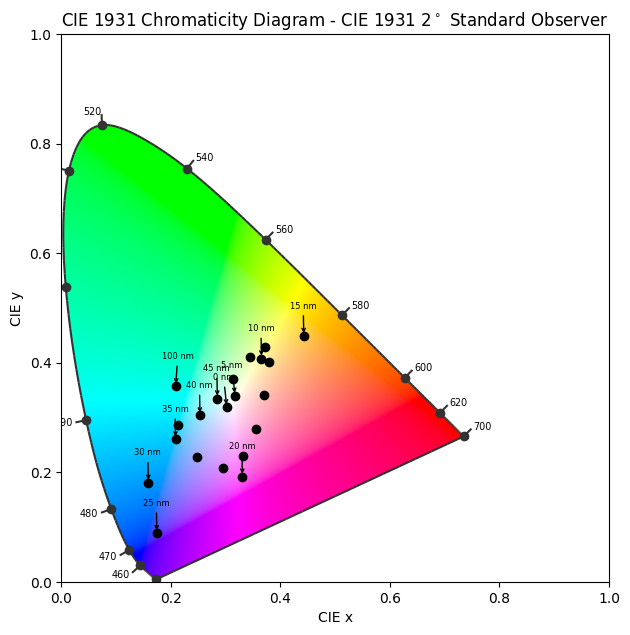

(<Figure size 640x640 with 1 Axes>,
 <Axes: title={'center': 'CIE 1931 Chromaticity Diagram - CIE 1931 2$^\\circ$ Standard Observer'}, xlabel='CIE x', ylabel='CIE y'>)

In [47]:
#To access the specific reflectivity spectra for a given thickness the index convention is as follows
#reflectivity_metal[0] --> spectra for 10 nm oxide thickness 
#reflectivity_metal[1] --> spectra for 15 nm oxide thickness 
#and so on and so forth in steps of 5 for each metal until you get to 100 nm thickness. 

#cmfs and illuminant are for modeling human perception of light 
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"] #cmfs == 'color mapping functions' as defined by the model in the argument, which is basically the
                                                                #default model that people use for human eyes 
illuminant = colour.SDS_ILLUMINANTS["D65"] #an illuminant is basically your light source spectrum. D = Daylight , 65 = 6500K color temperature --> 'average midday sunlight' 

gamuts = []

shape = colour.SpectralShape(380, 780, 1) #apparently, when computing the tristumlus values, which are essentially integrals (see doc), the interval
                                          #spacing for your wavelength has to be an integer of 1, 5, 10, or 20 nm, so if it's not, you need to interpolate 
                                          #over your wavelength range with one of these integer spacings 

# irregularly spaced data
wavelengths_old = wl_visible  #380 nm --> 780 nm, but not spaced by an integer of 1, 5, 10 or 20 nm. 

#Data I want to interpolate over 
wavelengths_new = np.arange(380, 781, 1)  #380 nm --> 780 nm, but spaced by an integer of 1 nm 

for i, thickness in enumerate(thickness_oxide): 
   
    R_curve = R_W_visible_norm[i, :] #defining the reflectivity that we need to interpolate over
    
    Pchip_R = PchipInterpolator(wavelengths_old, R_curve) #construct an interpolation 
    
    R_new = Pchip_R(wavelengths_new) #getting the interpolated values 

    spectrum_input = dict(zip(wavelengths_new, R_new)) #zip essentially takes two arrays with the same dimensions and creates tuples out of the elements in the same position
                                                              # GPT: 'pairs each wavelength with corresponding reflectivity value (truncates to shortest length if mismatched)'
    
    spectrum = colour.SpectralDistribution(dict(zip(wavelengths_new, R_new))).align(shape) #creates the spectral distribution of a structure with that Reflectivity at a given thickness
    
    XYZ = colour.sd_to_XYZ(spectrum, cmfs, illuminant) # converting the spectral distribution to tristimulus values, 
                                                       # X represents a visual response to red-green light, Y is the luminance/brightness, Z = blue response
    
    xy = colour.XYZ_to_xy(XYZ) #converts from tristimulus values to coordinates that can be plotted on a chromaticity diagram, each structure has one (x,y) coordinate
                               #this (x,y) coordinate tells us what color the stack is going to have under daylight illumination 

    gamuts.append(xy) #appends the coordinates to the array, and by plotting all of them we get the chromaticity diagram to show how color changes w/oxide thickness 

gamut_pts = np.array(gamuts) 

# Plotting the *CIE 1931 Chromaticity Diagram*.
# The argument *show=False* is passed so that the plot doesn't get
# displayed and can be used as a basis for other plots.

colour.plotting.plot_chromaticity_diagram_CIE1931(show=False)

# Plotting the *CIE xy* chromaticity coordinates.
x, y = gamut_pts[:, 0], gamut_pts[:, 1] #getting all the x-values and all the y-values 
plt.plot(x, y, "o", color = 'black') 

for i, thickness in enumerate(thickness_oxide):
    if i in [0, 1, 2 , 3, 4, 5, 6, 7, 8, 9, 20]:
        plt.annotate(f"{thickness} nm", xy = (x[i], y[i]), xytext=(-10, 20), textcoords="offset points", fontsize = 6, arrowprops=dict(arrowstyle="->", connectionstyle = "arc3, rad = 0.0"))

# Displaying the plot.
colour.plotting.render(show=True, limits=(-0.1, 0.9, -0.1, 0.9), x_tighten=True, y_tighten=True)